# Strip 1: first BANKSY run, interactive

Goal of this notebook: run BANKSY on `outputs/strip_01/adata_normalised.h5ad`
at a sweep of lambda values, see each step's output as it runs, and produce a
side-by-side comparison so I can read what each lambda is doing.

What lambda controls:
- `lambda = 0.0` ignores spatial neighbours, same as plain Leiden (baseline)
- `lambda ~ 0.2` is cell typing mode (rare immune cells should pop out)
- `lambda ~ 0.4` is balanced (cell type + a bit of tissue context)
- `lambda ~ 0.8` is tissue domain mode (epidermal zone, dermal zone, vascular zone)

After this notebook I'll have an annotated `adata_banksy.h5ad` with one cluster
column per lambda (e.g. `banksy_l0.2`) and a 4-panel UMAP comparison saved as a
PNG. The pipeline script `pipeline/03_banksy_cluster.py` does the same thing
headlessly for production runs; this notebook is for understanding the steps.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

from banksy.initialize_banksy import initialize_banksy
from banksy.embed_banksy import generate_banksy_matrix

ROI = 'strip_01'
OUT = Path(f'../../outputs/{ROI}')
FIG = OUT / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

LAMBDAS = [0.0, 0.2, 0.4, 0.8]
K_GEOM  = 6              # spatial neighbours per cell
RES     = 0.3            # Leiden resolution after BANKSY (matches prof's setting)
MAX_M   = 1              # include AGF (azimuthal gradient feature)

## 1. Load the normalised strip

In [2]:
a_full = ad.read_h5ad(OUT / 'adata_normalised.h5ad')
print(f'cells          : {a_full.n_obs:,}')
print(f'genes (total)  : {a_full.n_vars:,}')
print(f'genes (HVG)    : {int(a_full.var["highly_variable"].sum()):,}')
print(f'has x, y cols  : {set(["x","y"]).issubset(a_full.obs.columns)}')
print(f'has spatial    : {"spatial" in a_full.obsm}')

# Work with HVGs only (BANKSY scales with n_genes)
a_hvg = a_full[:, a_full.var['highly_variable']].copy()
print(f'\nworking matrix : {a_hvg.n_obs:,} cells x {a_hvg.n_vars:,} HVGs')

cells          : 7,921
genes (total)  : 21,053
genes (HVG)    : 2,979
has x, y cols  : True
has spatial    : True

working matrix : 7,921 cells x 2,979 HVGs


## 2. Initialise BANKSY (build spatial neighbour graph + neighbour features)

This builds, for every cell, its k=6 nearest spatial neighbours and computes
the neighbour-mean expression and the gradient feature (AGF).

In [3]:
banksy_dict = initialize_banksy(
    a_hvg,
    coord_keys=('x', 'y', 'spatial'),
    num_neighbours=K_GEOM,
    nbr_weight_decay='scaled_gaussian',
    max_m=MAX_M,
    plt_edge_hist=False,
    plt_nbr_weights=False,
    plt_agf_angles=False,
    plt_theta=False,
)


Median distance to closest cell = 28.73239195278016

---- Ran median_dist_to_nearest_neighbour in 0.01 s ----

---- Ran generate_spatial_distance_graph in 0.01 s ----

---- Ran row_normalize in 0.02 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.14 s ----

---- Ran generate_spatial_distance_graph in 0.02 s ----

---- Ran theta_from_spatial_graph in 0.04 s ----

---- Ran row_normalize in 0.02 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.19 s ----



## 3. Build the BANKSY matrix at each lambda

Stacks `[own_expression | mean_neighbour | AGF]` with weights set by lambda.
Returns a dict whose key path is `banksy_dict['scaled_gaussian'][lambda]['adata']`
and that inner AnnData's `.X` is the stacked feature matrix for that lambda.

In [4]:
banksy_dict, _ = generate_banksy_matrix(
    a_hvg, banksy_dict,
    lambda_list=LAMBDAS,
    max_m=MAX_M,
    plot_std=False,
    verbose=False,
)
print('lambdas built:', [k for k in banksy_dict['scaled_gaussian'] if isinstance(k, float)])

Check if X contains only finite (non-NAN) values
Decay Type: scaled_gaussian
Weights Object: {'weights': {0: <7921x7921 sparse matrix of type '<class 'numpy.float64'>'
	with 47526 stored elements in Compressed Sparse Row format>, 1: <7921x7921 sparse matrix of type '<class 'numpy.complex128'>'
	with 95052 stored elements in Compressed Sparse Row format>}}

Nbr matrix | Mean: 0.02 | Std: 0.16
Size of Nbr | Shape: (7921, 2979)
Top 3 entries of Nbr Mat:

[[2.08364531 5.36639325 4.21930914]
 [0.72630198 4.93247256 4.06914788]
 [0.6915178  4.76177042 4.00474915]]

AGF matrix | Mean: 0.02 | Std: 0.07
Size of AGF mat (m = 1) | Shape: (7921, 2979)
Top entries of AGF:
[[0.14808489 0.04780683 0.0234158 ]
 [0.12948781 0.11989395 0.12911618]
 [0.16340268 0.09459307 0.09148274]]
Ran 'Create BANKSY Matrix' in 0.02 mins
Scale factors squared: [1. 0. 0.]
Scale factors: [1. 0. 0.]
Scale factors squared: [0.8        0.13333333 0.06666667]
Scale factors: [0.89442719 0.36514837 0.25819889]
Scale factors s

## 4. For each lambda: PCA -> neighbours -> Leiden -> UMAP

We run a standard scanpy pipeline on each lambda's BANKSY matrix. The cluster
labels and UMAP coords get stored as separate columns on the main AnnData
(`a_full.obs['banksy_l0.2']`, `a_full.obsm['X_umap_l0.2']`, etc.).

In [5]:
results = {}
for lam in LAMBDAS:
    banksy_adata = banksy_dict['scaled_gaussian'][lam]['adata']
    a_lam = ad.AnnData(
        X=np.asarray(banksy_adata.X),
        obs=a_full.obs.copy(),
    )
    a_lam.obsm['spatial'] = a_full.obsm['spatial'].copy()

    sc.pp.pca(a_lam, n_comps=20)
    sc.pp.neighbors(a_lam, n_neighbors=15, n_pcs=20)
    sc.tl.leiden(a_lam, resolution=RES, random_state=0)
    sc.tl.umap(a_lam, random_state=0)

    labels = a_lam.obs['leiden'].astype(str)
    a_full.obs[f'banksy_l{lam}'] = labels.values
    a_full.obsm[f'X_umap_l{lam}'] = a_lam.obsm['X_umap']
    results[lam] = (labels, a_lam.obsm['X_umap'])
    print(f'lambda = {lam}  ->  {labels.nunique()} clusters')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


lambda = 0.0  ->  6 clusters
lambda = 0.2  ->  5 clusters
lambda = 0.4  ->  4 clusters
lambda = 0.8  ->  6 clusters


## 5. Side-by-side UMAP comparison

Each panel is one lambda. Watch how the cluster count and structure changes.
Low lambda should look like plain Leiden; high lambda should look like tissue zones.

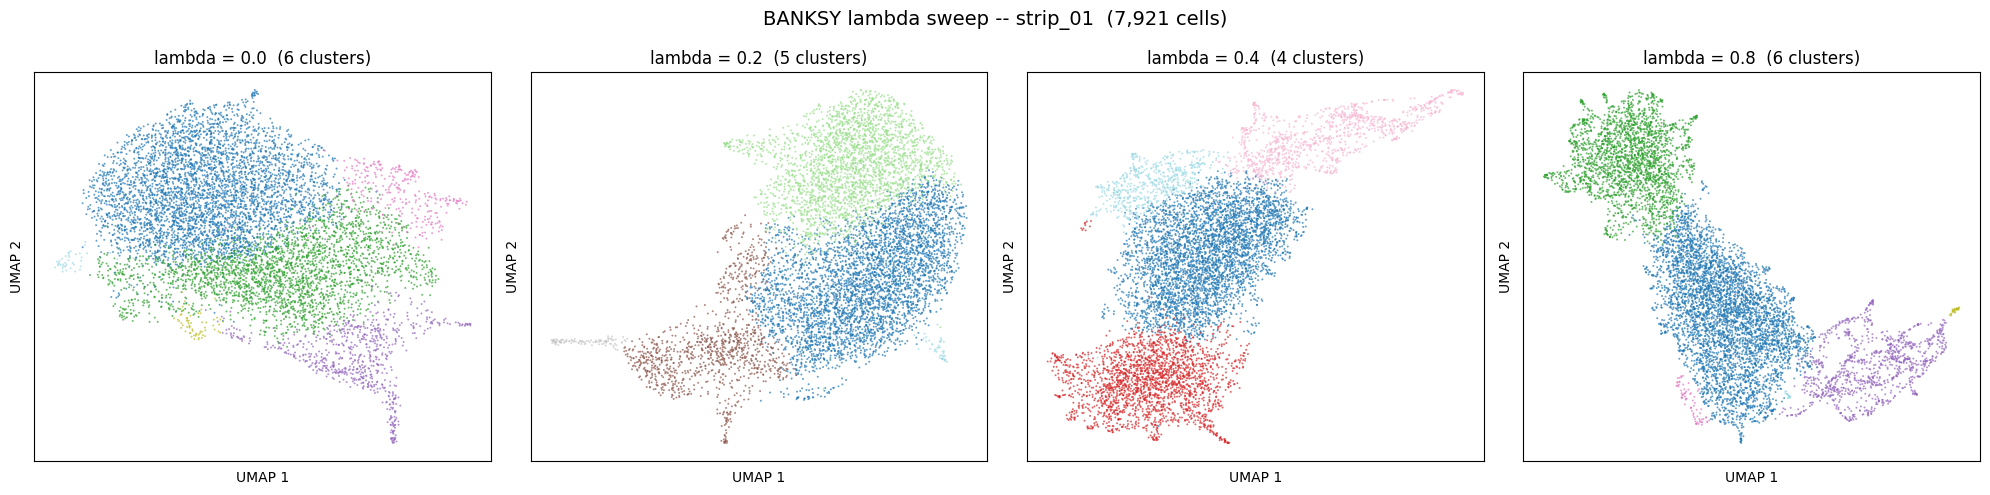

In [6]:
n = len(LAMBDAS)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
for ax, lam in zip(axes, LAMBDAS):
    labels, umap_xy = results[lam]
    cats = labels.astype('category')
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(cats.cat.categories), 1)))
    for i, c in enumerate(cats.cat.categories):
        mask = (labels == c).values
        ax.scatter(umap_xy[mask, 0], umap_xy[mask, 1],
                   s=2, color=colors[i], alpha=0.7, edgecolors='none', label=c)
    ax.set_title(f'lambda = {lam}  ({labels.nunique()} clusters)')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

fig.suptitle(f'BANKSY lambda sweep -- {ROI}  ({a_full.n_obs:,} cells)', fontsize=14)
plt.tight_layout()
plt.savefig(FIG / 'banksy_lambda_sweep.png', dpi=140, bbox_inches='tight')
plt.show()

## 6. Spatial maps per lambda

Same clusters, but plotted at each cell's actual chip position. Useful to see
whether high-lambda clusters look like coherent tissue regions on the strip.

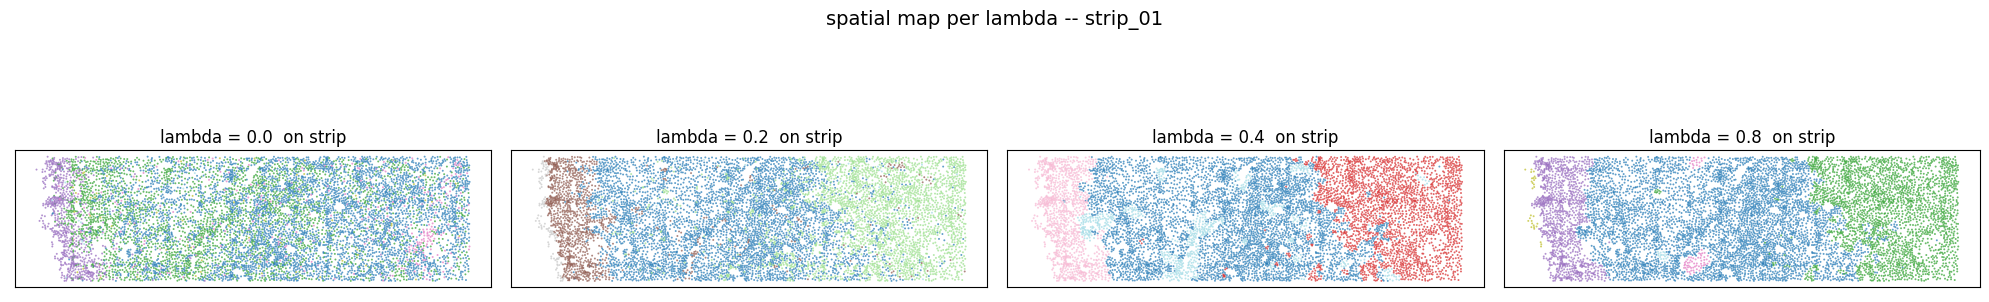

In [7]:
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
xy = a_full.obsm['spatial']
for ax, lam in zip(axes, LAMBDAS):
    labels = results[lam][0]
    cats = labels.astype('category')
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(cats.cat.categories), 1)))
    for i, c in enumerate(cats.cat.categories):
        mask = (labels == c).values
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   s=2, color=colors[i], alpha=0.7, edgecolors='none')
    ax.invert_yaxis(); ax.set_aspect('equal')
    ax.set_title(f'lambda = {lam}  on strip')
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f'spatial map per lambda -- {ROI}', fontsize=14)
plt.tight_layout()
plt.savefig(FIG / 'banksy_spatial_sweep.png', dpi=140, bbox_inches='tight')
plt.show()

## 7. Save the augmented AnnData

Stores the cluster labels and UMAPs on the main AnnData and writes it to
`adata_banksy.h5ad` for use by the next step (annotation).

In [8]:
out_path = OUT / 'adata_banksy.h5ad'
a_full.write_h5ad(out_path)
print(f'wrote {out_path}  ({out_path.stat().st_size / 1e6:.1f} MB)')

wrote ../../outputs/strip_01/adata_banksy.h5ad  (86.0 MB)


## What to look at

Open the two saved figures and ask:

1. **UMAP sweep**: does the number of clusters change as lambda increases? Do clusters get cleaner / more separated, or do they merge into bigger groups?
2. **Spatial sweep**: at high lambda, do the clusters form coherent stripes/bands on the tissue (consistent with epidermal vs dermal zones)? At low lambda, do they look more like scattered cells of mixed types?

The next step (notebook 03 or `pipeline/04_annotate.py`) will take whichever lambda's clusters look the most useful and label them by marker genes.

In [10]:
# Workaround for a scanpy 1.9 quirk: log1p stored its key without 'base'
if 'log1p' in a_full.uns and 'base' not in a_full.uns['log1p']:
    a_full.uns['log1p']['base'] = None

In [11]:
# Find top marker genes per cluster at lambda = 0.2
import scanpy as sc

# Make sure we use raw counts for the comparison (not BANKSY's mixed matrix)
sc.tl.rank_genes_groups(
    a_full,
    groupby='banksy_l0.2',
    method='wilcoxon',
    use_raw=False,
)

# Print top 15 genes per cluster
import pandas as pd
result = a_full.uns['rank_genes_groups']
top = pd.DataFrame({c: result['names'][c][:15] for c in result['names'].dtype.names})
print(top)

         0                1       2       3                4
0    POSTN           COL1A1    KRT1   KRT10  ENSG00000288560
1   COL3A1          MT-RNR2   KRT10    KRT1  ENSG00000242628
2    SPARC            IGHG1  KRTDAP  KRTDAP             SBF2
3      FN1            IGHG4   KRT14  S100A7           MALAT1
4   COL1A2             RYR2  S100A8    DMKN            LAMP5
5   LGALS1           MALAT1  S100A9    PERP         C12orf57
6    HTRA1            DCLK1     SFN  S100A8            RPL41
7    TGFBI            DLEU2  S100A7    SBSN            SPON2
8      FTL             GPC6    DMKN  S100A9  ENSG00000291121
9     COMP            SFRP4   HLA-B    DSG1              MGP
10  COL5A1             BNC2     B2M    KRT2              MN1
11  COL1A1         TCF4-AS1    RPS8  CASP14            POSTN
12    NBL1           LRRC4C   HSPB1   FABP5            HIF1A
13  COL5A2            CCER2    KRT5     JUP            CLIC1
14  TMSB10  ENSG00000254420    RPL3     DSP             AQP1


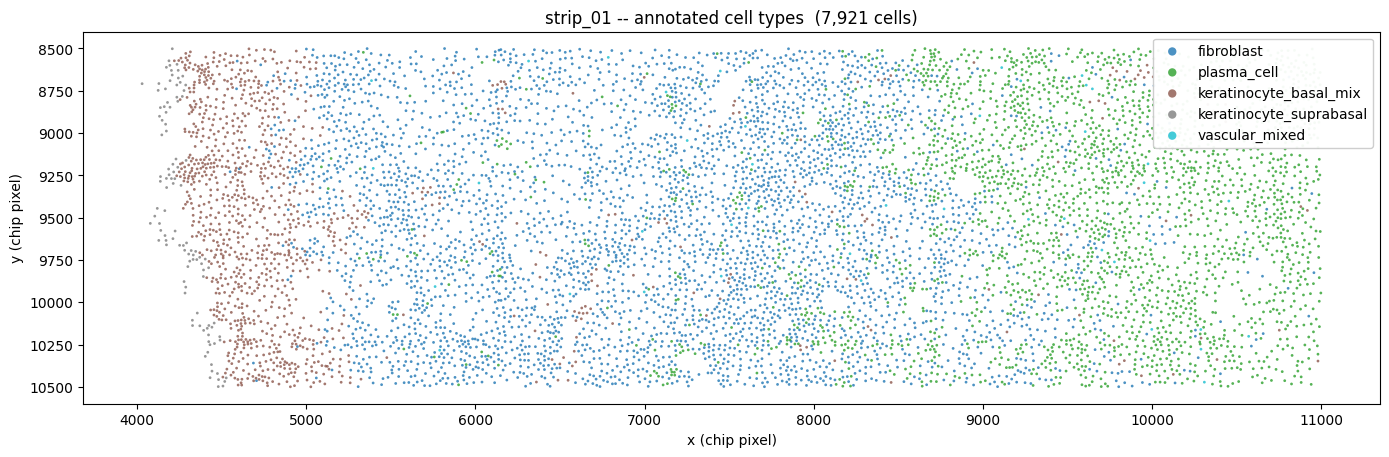


saved with labels: ../../outputs/strip_01/adata_annotated.h5ad

cell counts per type:
fibroblast                 4140
plasma_cell                2528
keratinocyte_basal_mix     1103
keratinocyte_suprabasal     106
vascular_mixed               44
Name: celltype, dtype: int64


In [12]:
# A. Apply our cell-type labels
labels_map = {
    '0': 'fibroblast',
    '1': 'plasma_cell',
    '2': 'keratinocyte_basal_mix',
    '3': 'keratinocyte_suprabasal',
    '4': 'vascular_mixed',
}
a_full.obs['celltype'] = a_full.obs['banksy_l0.2'].map(labels_map)

# C. Plot the labelled cells on the strip
import matplotlib.pyplot as plt
import numpy as np

xy = a_full.obsm['spatial']
cats = a_full.obs['celltype'].astype('category')
colors = plt.cm.tab10(np.linspace(0, 1, len(cats.cat.categories)))

fig, ax = plt.subplots(figsize=(14, 5))
for i, c in enumerate(cats.cat.categories):
    mask = (a_full.obs['celltype'] == c).values
    ax.scatter(xy[mask, 0], xy[mask, 1],
               s=4, color=colors[i], alpha=0.8, edgecolors='none', label=c)
ax.invert_yaxis(); ax.set_aspect('equal')
ax.set_xlabel('x (chip pixel)'); ax.set_ylabel('y (chip pixel)')
ax.set_title(f'strip_01 -- annotated cell types  ({a_full.n_obs:,} cells)')
ax.legend(loc='upper right', markerscale=3, framealpha=0.95)
plt.tight_layout()
plt.savefig(FIG / 'strip01_annotated_celltypes.png', dpi=140, bbox_inches='tight')
plt.show()

# Save AnnData with the new label
a_full.write_h5ad(OUT / 'adata_annotated.h5ad')
print(f'\nsaved with labels: {OUT / "adata_annotated.h5ad"}')
print('\ncell counts per type:')
print(a_full.obs['celltype'].value_counts())

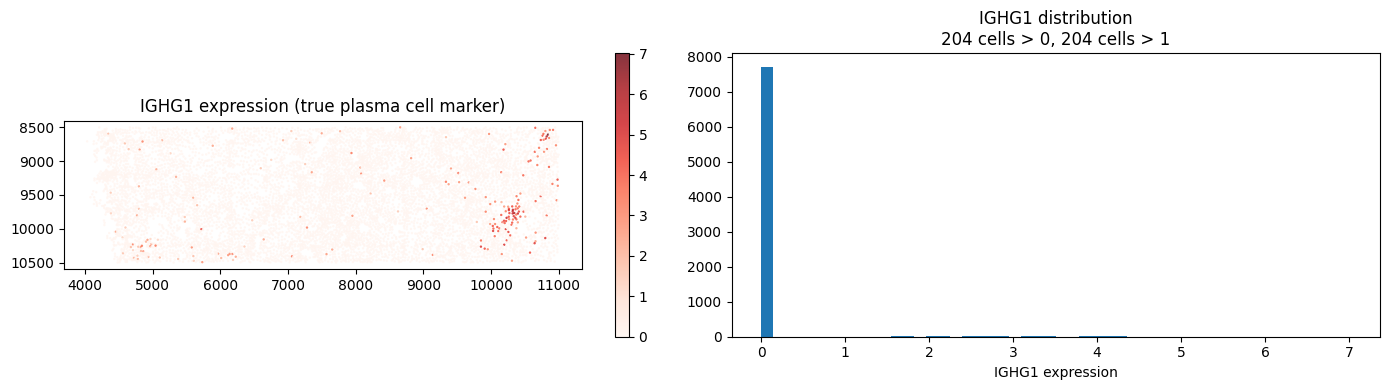

IGHG1+ cells INSIDE the plasma_cell cluster : 123 / 2,528
IGHG1+ cells OUTSIDE the plasma_cell cluster: 81 / 5,393


In [13]:
import scanpy as sc
import matplotlib.pyplot as plt

# Plot IGHG1 expression across cells (so we see WHERE the plasma cell signal is)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Spatial map coloured by IGHG1 expression
ighg1 = a_full[:, 'IGHG1'].X
ighg1 = ighg1.toarray().flatten() if hasattr(ighg1, 'toarray') else ighg1.flatten()
xy = a_full.obsm['spatial']
sc = axes[0].scatter(xy[:, 0], xy[:, 1], c=ighg1, s=3, cmap='Reds',
                     alpha=0.8, edgecolors='none')
axes[0].invert_yaxis(); axes[0].set_aspect('equal')
axes[0].set_title('IGHG1 expression (true plasma cell marker)')
plt.colorbar(sc, ax=axes[0])

# How many cells actually express IGHG1 above zero?
n_express  = int((ighg1 > 0).sum())
n_high     = int((ighg1 > 1).sum())
axes[1].hist(ighg1, bins=50)
axes[1].set_title(f'IGHG1 distribution\n{n_express} cells > 0, {n_high} cells > 1')
axes[1].set_xlabel('IGHG1 expression')

plt.tight_layout()
plt.show()

# What fraction of "plasma_cell" cluster actually expresses IGHG1?
in_cluster = (a_full.obs['celltype'] == 'plasma_cell')
expr_in   = int((ighg1[in_cluster] > 0).sum())
expr_out  = int((ighg1[~in_cluster] > 0).sum())
print(f'IGHG1+ cells INSIDE the plasma_cell cluster : {expr_in:,} / {int(in_cluster.sum()):,}')
print(f'IGHG1+ cells OUTSIDE the plasma_cell cluster: {expr_out:,} / {int((~in_cluster).sum()):,}')

In [14]:
# Relabel cluster 1 honestly: it's deep dermal stromal, with plasma cells mixed in.
labels_map = {
    '0': 'fibroblast',
    '1': 'deep_dermal_stromal',          # was 'plasma_cell' -- corrected
    '2': 'keratinocyte_basal_mix',
    '3': 'keratinocyte_suprabasal',
    '4': 'vascular_mixed',
}
a_full.obs['celltype'] = a_full.obs['banksy_l0.2'].map(labels_map)

# Also flag the actual plasma cells using IGHG1 expression directly,
# regardless of which cluster they fell into.
import numpy as np
ighg1 = a_full[:, 'IGHG1'].X
ighg1 = ighg1.toarray().flatten() if hasattr(ighg1, 'toarray') else ighg1.flatten()
a_full.obs['is_plasma_cell'] = ighg1 > 0   # True for the 204 IGHG1+ cells

n_plasma = int(a_full.obs['is_plasma_cell'].sum())
print(f'\nrelabel done.')
print(f'flagged {n_plasma} IGHG1+ cells as plasma cells (separate annotation layer)')
print('\ncell counts per type:')
print(a_full.obs['celltype'].value_counts())

# Save
a_full.write_h5ad(OUT / 'adata_annotated.h5ad')
print(f'\nsaved: {OUT / "adata_annotated.h5ad"}')


relabel done.
flagged 204 IGHG1+ cells as plasma cells (separate annotation layer)

cell counts per type:
fibroblast                 4140
deep_dermal_stromal        2528
keratinocyte_basal_mix     1103
keratinocyte_suprabasal     106
vascular_mixed               44
Name: celltype, dtype: int64

saved: ../../outputs/strip_01/adata_annotated.h5ad


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

# A. Check if other plasma cell markers agree with IGHG1
plasma_markers = ['IGHG1', 'IGHG2', 'IGHG3', 'IGHG4', 'JCHAIN', 'MZB1',
                  'IGKC', 'IGLC2', 'CD79A', 'XBP1']
plasma_in_data = [g for g in plasma_markers if g in a_full.var_names]
print(f'Plasma markers found in data: {plasma_in_data}')

# B. Check if "plasma cells" co-express markers of other cell types (= doublets)
other_markers = ['KRT14', 'COL1A1', 'PECAM1', 'CD3D']
other_in_data = [g for g in other_markers if g in a_full.var_names]

plasma_cells = a_full.obs['is_plasma_cell']

# Mean expression per marker, INSIDE plasma cells vs OUTSIDE
def mean_expr(adata, gene_list, mask):
    out = {}
    for g in gene_list:
        x = adata[:, g].X
        x = x.toarray().flatten() if hasattr(x, 'toarray') else x.flatten()
        out[g] = (x[mask].mean(), x[~mask].mean())
    return out

print('\n--- Plasma cell markers ---')
print(f'{"gene":<10} {"in IGHG1+ cells":>16} {"in other cells":>16} {"fold change":>12}')
for g, (m_in, m_out) in mean_expr(a_full, plasma_in_data, plasma_cells).items():
    fc = m_in / max(m_out, 1e-6)
    print(f'{g:<10} {m_in:>16.3f} {m_out:>16.3f} {fc:>12.1f}x')

print('\n--- "Doublet check": other-cell-type markers ---')
print(f'{"gene":<10} {"in IGHG1+ cells":>16} {"in other cells":>16}')
for g, (m_in, m_out) in mean_expr(a_full, other_in_data, plasma_cells).items():
    print(f'{g:<10} {m_in:>16.3f} {m_out:>16.3f}')

Plasma markers found in data: ['IGHG1', 'IGHG2', 'IGHG3', 'IGHG4', 'JCHAIN', 'MZB1', 'IGKC', 'IGLC2', 'CD79A', 'XBP1']

--- Plasma cell markers ---
gene        in IGHG1+ cells   in other cells  fold change
IGHG1                 3.159            0.000    3158742.6x
IGHG2                 0.217            0.002        140.4x
IGHG3                 0.814            0.057         14.2x
IGHG4                 2.277            0.094         24.2x
JCHAIN                0.102            0.028          3.6x
MZB1                  0.000            0.003          0.0x
IGKC                  1.642            0.253          6.5x
IGLC2                 0.150            0.023          6.5x
CD79A                 0.012            0.005          2.3x
XBP1                  0.248            0.190          1.3x

--- "Doublet check": other-cell-type markers ---
gene        in IGHG1+ cells   in other cells
KRT14                 1.141            1.087
COL1A1                6.416            6.685
PECAM1             

plasma cells: 204
median nearest-neighbour distance, plasma cells: 76.8 px
median nearest-neighbour distance, random sample: 129.4 px
ratio (plasma / random): 0.59
ratio < 0.7 -> plasma cells are spatially CLUSTERED (closer than random)
ratio ~ 1.0 -> plasma cells are randomly scattered


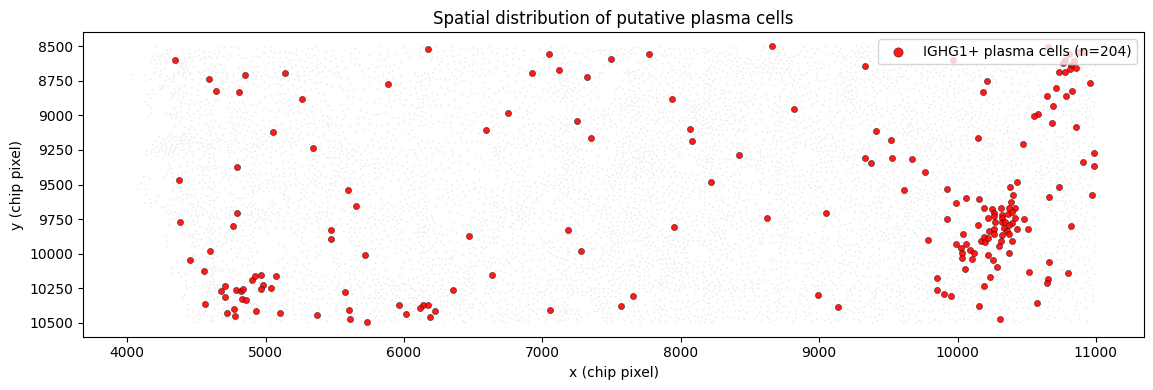

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

xy = a_full.obsm['spatial']
mask = a_full.obs['is_plasma_cell'].values
plasma_xy = xy[mask]
other_xy  = xy[~mask]
n_plasma = len(plasma_xy)

# Median nearest-neighbour distance among plasma cells
d = cdist(plasma_xy, plasma_xy)
np.fill_diagonal(d, np.inf)
nn_plasma = d.min(axis=1)
median_nn_plasma = float(np.median(nn_plasma))

# Compare to: random sample of same size from all cells
rng = np.random.default_rng(0)
rand_xy = xy[rng.choice(len(xy), n_plasma, replace=False)]
d2 = cdist(rand_xy, rand_xy); np.fill_diagonal(d2, np.inf)
median_nn_random = float(np.median(d2.min(axis=1)))

print(f'plasma cells: {n_plasma}')
print(f'median nearest-neighbour distance, plasma cells: {median_nn_plasma:.1f} px')
print(f'median nearest-neighbour distance, random sample: {median_nn_random:.1f} px')
print(f'ratio (plasma / random): {median_nn_plasma / median_nn_random:.2f}')
print('ratio < 0.7 -> plasma cells are spatially CLUSTERED (closer than random)')
print('ratio ~ 1.0 -> plasma cells are randomly scattered')

# Spatial plot: plasma cells on top of grey background
fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(other_xy[:, 0], other_xy[:, 1], s=2, c='lightgrey', alpha=0.4, edgecolors='none')
ax.scatter(plasma_xy[:, 0], plasma_xy[:, 1], s=20, c='red', alpha=0.9, edgecolors='black', linewidth=0.3, label=f'IGHG1+ plasma cells (n={n_plasma})')
ax.invert_yaxis(); ax.set_aspect('equal')
ax.set_title('Spatial distribution of putative plasma cells')
ax.set_xlabel('x (chip pixel)'); ax.set_ylabel('y (chip pixel)')
ax.legend(loc='upper right', markerscale=1.5)
plt.tight_layout(); plt.show()

In [17]:
import scanpy as sc
import matplotlib.pyplot as plt

# Subset the cluster we want to dig into
sub = a_full[a_full.obs['celltype'] == 'deep_dermal_stromal'].copy()
print(f'sub-clustering {sub.n_obs:,} deep_dermal_stromal cells')

# Fresh PCA/neighbours/Leiden ON JUST THESE CELLS at higher resolution
# (higher resolution -> finer sub-clusters)
sc.pp.highly_variable_genes(sub, n_top_genes=2000, flavor='seurat', subset=False)
sc.pp.scale(sub, max_value=10)
sc.tl.pca(sub, n_comps=30)
sc.pp.neighbors(sub, n_neighbors=15, n_pcs=30)
sc.tl.leiden(sub, resolution=0.6, random_state=0, key_added='sub_leiden')
sc.tl.umap(sub, random_state=0)

print(f'sub-clusters found: {sub.obs["sub_leiden"].nunique()}')
print(sub.obs['sub_leiden'].value_counts().sort_index())

# Which sub-cluster is enriched for IGHG1+ cells?
ighg1 = sub[:, 'IGHG1'].X
ighg1 = ighg1.toarray().flatten() if hasattr(ighg1, 'toarray') else ighg1.flatten()
sub.obs['ighg1_pos'] = ighg1 > 0

enrich = sub.obs.groupby('sub_leiden')['ighg1_pos'].agg(['sum', 'count'])
enrich['fraction_ighg1_pos'] = enrich['sum'] / enrich['count']
print('\nIGHG1+ fraction per sub-cluster:')
print(enrich.sort_values('fraction_ighg1_pos', ascending=False))

sub-clustering 2,528 deep_dermal_stromal cells
sub-clusters found: 6
0    1174
1    1043
2     142
3      86
4      42
5      41
Name: sub_leiden, dtype: int64

IGHG1+ fraction per sub-cluster:
            sum  count  fraction_ighg1_pos
sub_leiden                                
2            93    142            0.654930
3             4     86            0.046512
4             1     42            0.023810
1            17   1043            0.016299
0             8   1174            0.006814
5             0     41            0.000000


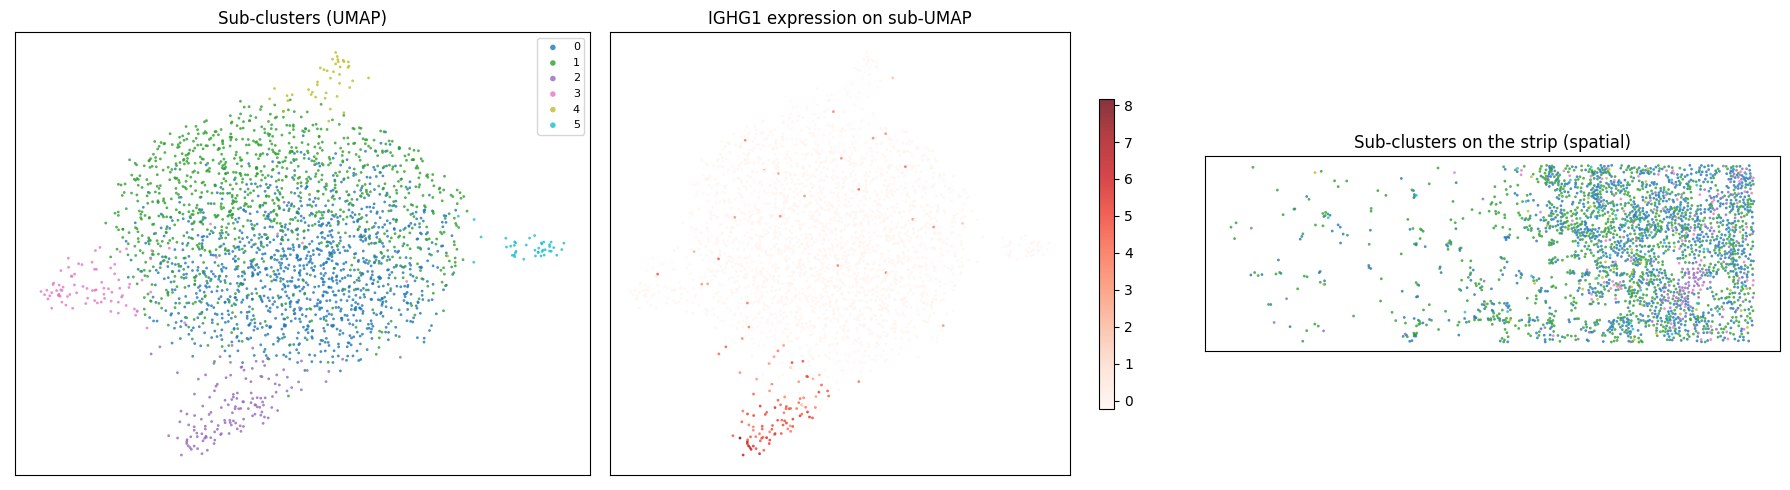

In [18]:
# Visualise: 3 panels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: sub-cluster UMAP
import numpy as np
cats = sub.obs['sub_leiden'].astype('category')
colors = plt.cm.tab10(np.linspace(0, 1, len(cats.cat.categories)))
for i, c in enumerate(cats.cat.categories):
    m = (sub.obs['sub_leiden'] == c).values
    axes[0].scatter(sub.obsm['X_umap'][m, 0], sub.obsm['X_umap'][m, 1],
                    s=4, color=colors[i], alpha=0.8, edgecolors='none', label=c)
axes[0].set_title('Sub-clusters (UMAP)')
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].legend(loc='best', fontsize=8, markerscale=2)

# Panel 2: IGHG1 expression on the same UMAP
sc1 = axes[1].scatter(sub.obsm['X_umap'][:, 0], sub.obsm['X_umap'][:, 1],
                      c=ighg1, cmap='Reds', s=4, alpha=0.8, edgecolors='none')
axes[1].set_title('IGHG1 expression on sub-UMAP')
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.colorbar(sc1, ax=axes[1], shrink=0.7)

# Panel 3: sub-clusters back on the strip's spatial map
xy_sub = sub.obsm['spatial']
for i, c in enumerate(cats.cat.categories):
    m = (sub.obs['sub_leiden'] == c).values
    axes[2].scatter(xy_sub[m, 0], xy_sub[m, 1],
                    s=4, color=colors[i], alpha=0.8, edgecolors='none', label=c)
axes[2].invert_yaxis(); axes[2].set_aspect('equal')
axes[2].set_title('Sub-clusters on the strip (spatial)')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout(); plt.show()

isolating 142 plasma cells from sub-cluster 2

refined cell counts:
fibroblast                 4140
deep_dermal_stromal        2386
keratinocyte_basal_mix     1103
plasma_cell                 142
keratinocyte_suprabasal     106
vascular_mixed               44
Name: celltype_refined, dtype: int64

saved: ../../outputs/strip_01/adata_annotated.h5ad


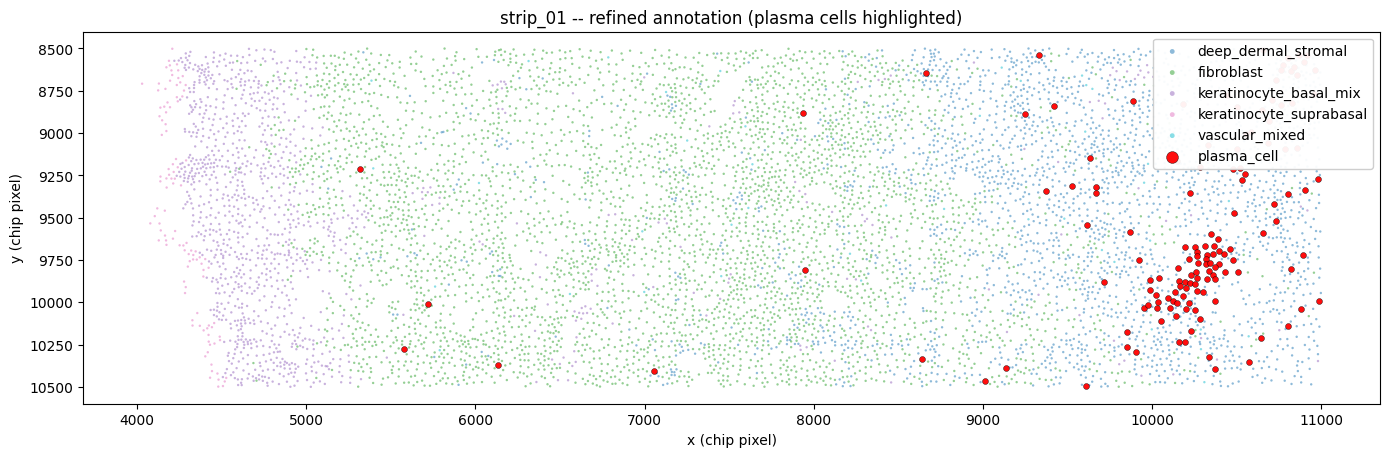

In [19]:
# The plasma cell sub-cluster is sub_leiden = '2' (65.5% IGHG1+)
PLASMA_SUB = '2'
plasma_cell_ids = sub.obs.index[sub.obs['sub_leiden'] == PLASMA_SUB]
print(f'isolating {len(plasma_cell_ids)} plasma cells from sub-cluster {PLASMA_SUB}')

# Build a refined cell type column on the main AnnData
a_full.obs['celltype_refined'] = a_full.obs['celltype'].astype(str)
a_full.obs.loc[plasma_cell_ids, 'celltype_refined'] = 'plasma_cell'

print('\nrefined cell counts:')
print(a_full.obs['celltype_refined'].value_counts())

# Save
a_full.write_h5ad(OUT / 'adata_annotated.h5ad')
print(f'\nsaved: {OUT / "adata_annotated.h5ad"}')

# Replot the strip with refined labels
import matplotlib.pyplot as plt
import numpy as np
xy = a_full.obsm['spatial']
cats = a_full.obs['celltype_refined'].astype('category')
colors = plt.cm.tab10(np.linspace(0, 1, len(cats.cat.categories)))

fig, ax = plt.subplots(figsize=(14, 5))
# Plot non-plasma first
for i, c in enumerate(cats.cat.categories):
    if c == 'plasma_cell': continue
    m = (a_full.obs['celltype_refined'] == c).values
    ax.scatter(xy[m, 0], xy[m, 1], s=3, color=colors[i], alpha=0.5, edgecolors='none', label=c)
# Plot plasma cells last (on top, bigger)
m = (a_full.obs['celltype_refined'] == 'plasma_cell').values
ax.scatter(xy[m, 0], xy[m, 1], s=18, color='red', alpha=0.95,
           edgecolors='black', linewidth=0.3, label='plasma_cell')

ax.invert_yaxis(); ax.set_aspect('equal')
ax.set_xlabel('x (chip pixel)'); ax.set_ylabel('y (chip pixel)')
ax.set_title('strip_01 -- refined annotation (plasma cells highlighted)')
ax.legend(loc='upper right', markerscale=2, framealpha=0.95)
plt.tight_layout()
plt.savefig(FIG / 'strip01_annotated_refined.png', dpi=140, bbox_inches='tight')
plt.show()

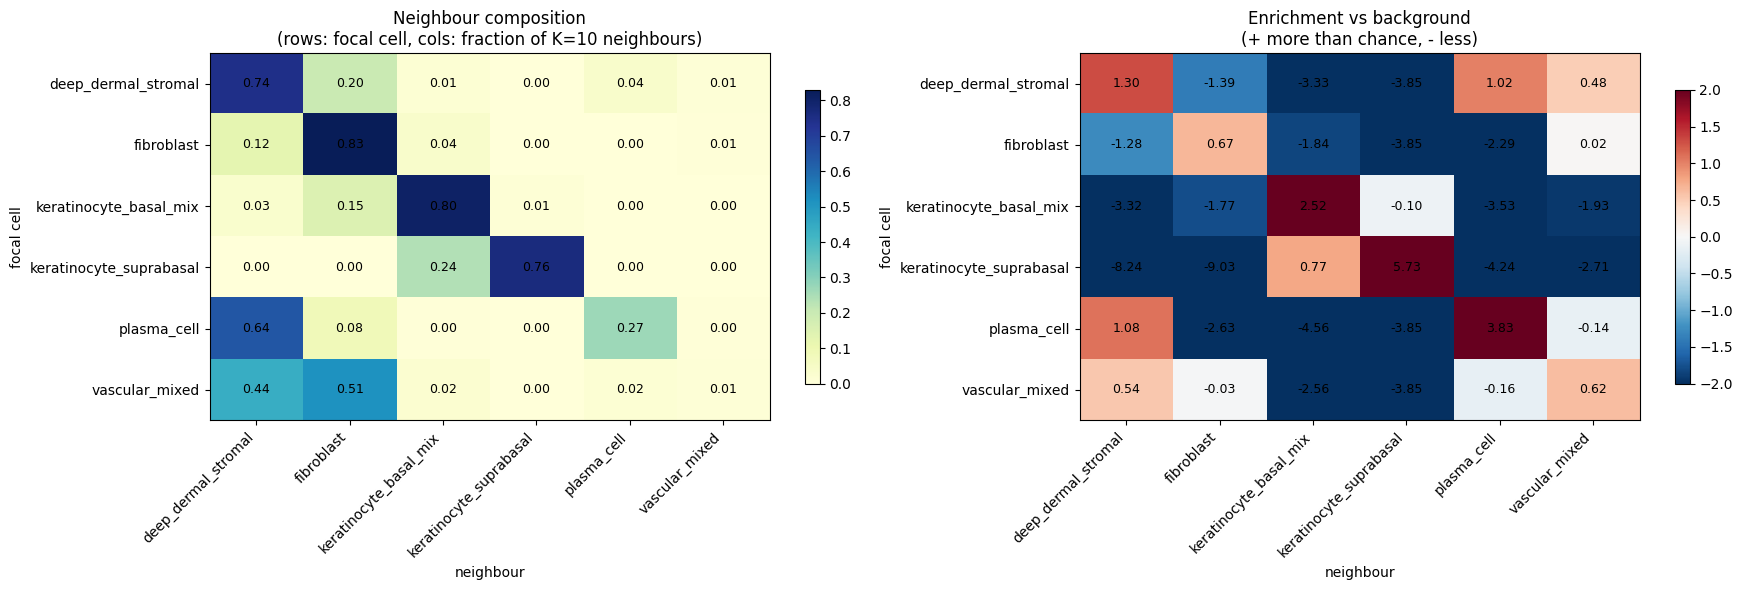

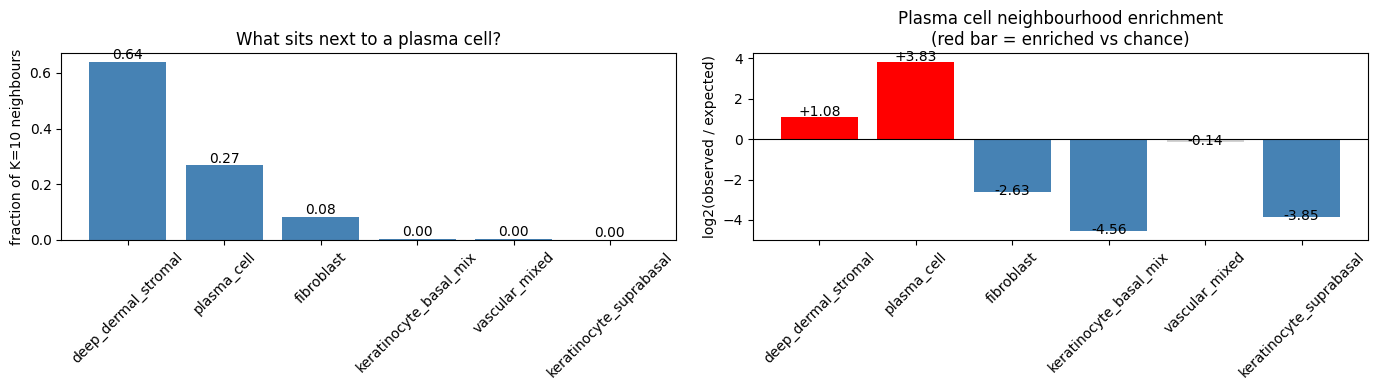


=== Top 3 cell types enriched in plasma cell neighbourhoods ===
plasma_cell            3.826970
deep_dermal_stromal    1.081847
vascular_mixed        -0.144634
Name: plasma_cell, dtype: float64


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# 1. Build a spatial k-nearest-neighbour graph.
# For each cell, find its K nearest cells on the chip.
K = 10
nn = NearestNeighbors(n_neighbors=K + 1).fit(a_full.obsm['spatial'])
_, idx = nn.kneighbors(a_full.obsm['spatial'])
idx = idx[:, 1:]                                              # drop self

# 2. For each cell, get the cell-type label of its K neighbours.
celltype = a_full.obs['celltype_refined'].astype(str).to_numpy()
neighbour_types = celltype[idx]                                # (n_cells, K)

# 3. For each focal cell type, compute mean neighbour composition.
types = sorted(set(celltype))
comp = pd.DataFrame(0.0, index=types, columns=types)
for focal in types:
    focal_mask = celltype == focal
    nb = neighbour_types[focal_mask].flatten()
    counts = pd.Series(nb).value_counts(normalize=True)
    for t in types:
        comp.loc[focal, t] = counts.get(t, 0.0)

# 4. Compare to background expectation (overall cell type frequencies).
bg = pd.Series(celltype).value_counts(normalize=True).reindex(types)
log2_enrich = np.log2((comp + 1e-3).div(bg + 1e-3, axis=1))

# 5. Plot: two heatmaps + a focused bar chart for plasma cells.
def heatmap(ax, data, title, cmap, center=None):
    vmax = 2 if center == 0 else data.values.max()
    vmin = -2 if center == 0 else 0
    im = ax.imshow(data.values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(data.columns))); ax.set_xticklabels(data.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(data.index))); ax.set_yticklabels(data.index)
    ax.set_title(title); ax.set_xlabel('neighbour'); ax.set_ylabel('focal cell')
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            ax.text(j, i, f'{data.values[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, color='black')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
heatmap(axes[0], comp, 'Neighbour composition\n(rows: focal cell, cols: fraction of K=10 neighbours)', 'YlGnBu')
heatmap(axes[1], log2_enrich, 'Enrichment vs background\n(+ more than chance, - less)', 'RdBu_r', center=0)
plt.tight_layout()
plt.savefig(FIG / 'neighbourhood_enrichment.png', dpi=140, bbox_inches='tight')
plt.show()

# 6. Focused: bar chart for plasma cells specifically.
plasma_comp = comp.loc['plasma_cell'].sort_values(ascending=False)
plasma_enrich = log2_enrich.loc['plasma_cell'].reindex(plasma_comp.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(plasma_comp.index, plasma_comp.values, color='steelblue')
axes[0].set_ylabel('fraction of K=10 neighbours')
axes[0].set_title('What sits next to a plasma cell?')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(plasma_comp.values):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)

colors_e = ['red' if v > 0.5 else ('darkred' if v > 1 else ('lightgrey' if abs(v) < 0.3 else 'steelblue')) for v in plasma_enrich.values]
axes[1].bar(plasma_enrich.index, plasma_enrich.values, color=colors_e)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('log2(observed / expected)')
axes[1].set_title('Plasma cell neighbourhood enrichment\n(red bar = enriched vs chance)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(plasma_enrich.values):
    axes[1].text(i, v + (0.05 if v > 0 else -0.15), f'{v:+.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIG / 'plasma_neighbourhood.png', dpi=140, bbox_inches='tight')
plt.show()

print('\n=== Top 3 cell types enriched in plasma cell neighbourhoods ===')
print(plasma_enrich.sort_values(ascending=False).head(3))